<a href="https://colab.research.google.com/github/sampurnashaw/AI-LAB/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 3: Checking Routes Between Cities Using DFS
Problem Statement:
A small road network connects several cities. Write a Python program using DFS that:
1. Checks whether a route exists between two given cities.
2. Finds all separate groups of cities that are connected to each other but not to any
other group (these are called connected components).

In [1]:
# Define the road network (graph) using Indian city names
# This is an undirected graph, so connections are bidirectional.
road_network = {
    'Delhi': ['Mumbai', 'Jaipur'],
    'Mumbai': ['Delhi', 'Bengaluru', 'Ahmedabad'],
    'Jaipur': ['Delhi', 'Udaipur'],
    'Bengaluru': ['Mumbai', 'Chennai', 'Hyderabad'],
    'Chennai': ['Bengaluru', 'Hyderabad'],
    'Hyderabad': ['Bengaluru', 'Chennai'],
    'Ahmedabad': ['Mumbai'],
    'Kolkata': ['Bhubaneswar'],
    'Bhubaneswar': ['Kolkata']
}


In [2]:
def check_route(graph, start_city, end_city):
    """
    Checks if a route exists between two cities using DFS.
    """
    if start_city not in graph or end_city not in graph:
        return False

    visited = set()
    stack = [start_city]

    while stack:
        current_city = stack.pop()
        if current_city == end_city:
            return True
        if current_city not in visited:
            visited.add(current_city)
            for neighbor in graph.get(current_city, []):
                if neighbor not in visited:
                    stack.append(neighbor)
    return False


In [3]:
def find_connected_components(graph):
    """
    Finds all separate groups of cities that are connected to each other.
    """
    visited = set()
    components = []

    for city in graph:
        if city not in visited:
            current_component = set()
            stack = [city]
            visited.add(city)

            while stack:
                node = stack.pop()
                current_component.add(node)
                for neighbor in graph.get(node, []):
                    if neighbor not in visited:
                        visited.add(neighbor)
                        stack.append(neighbor)
            components.append(sorted(list(current_component)))
    return components

In [4]:
# Test cases for route checking
print("Route from Delhi to Chennai exists:", check_route(road_network, 'Delhi', 'Chennai'))
print("Route from Delhi to Kolkata exists:", check_route(road_network, 'Delhi', 'Kolkata'))
print("Route from Mumbai to Ahmedabad exists:", check_route(road_network, 'Mumbai', 'Ahmedabad'))
print("Route from Jaipur to Bengaluru exists:", check_route(road_network, 'Jaipur', 'Bengaluru'))
print("Route from Kolkata to Bhubaneswar exists:", check_route(road_network, 'Kolkata', 'Bhubaneswar'))
print("Route from Bengaluru to Delhi exists:", check_route(road_network, 'Bengaluru', 'Delhi'))

Route from Delhi to Chennai exists: True
Route from Delhi to Kolkata exists: False
Route from Mumbai to Ahmedabad exists: True
Route from Jaipur to Bengaluru exists: True
Route from Kolkata to Bhubaneswar exists: True
Route from Bengaluru to Delhi exists: True


In [5]:
# Test cases for finding connected components
connected_groups = find_connected_components(road_network)
print("Separate groups of connected cities:")
for group in connected_groups:
    print(group)

Separate groups of connected cities:
['Ahmedabad', 'Bengaluru', 'Chennai', 'Delhi', 'Hyderabad', 'Jaipur', 'Mumbai', 'Udaipur']
['Bhubaneswar', 'Kolkata']


In [6]:
# Install networkx if not already installed
!pip install networkx matplotlib

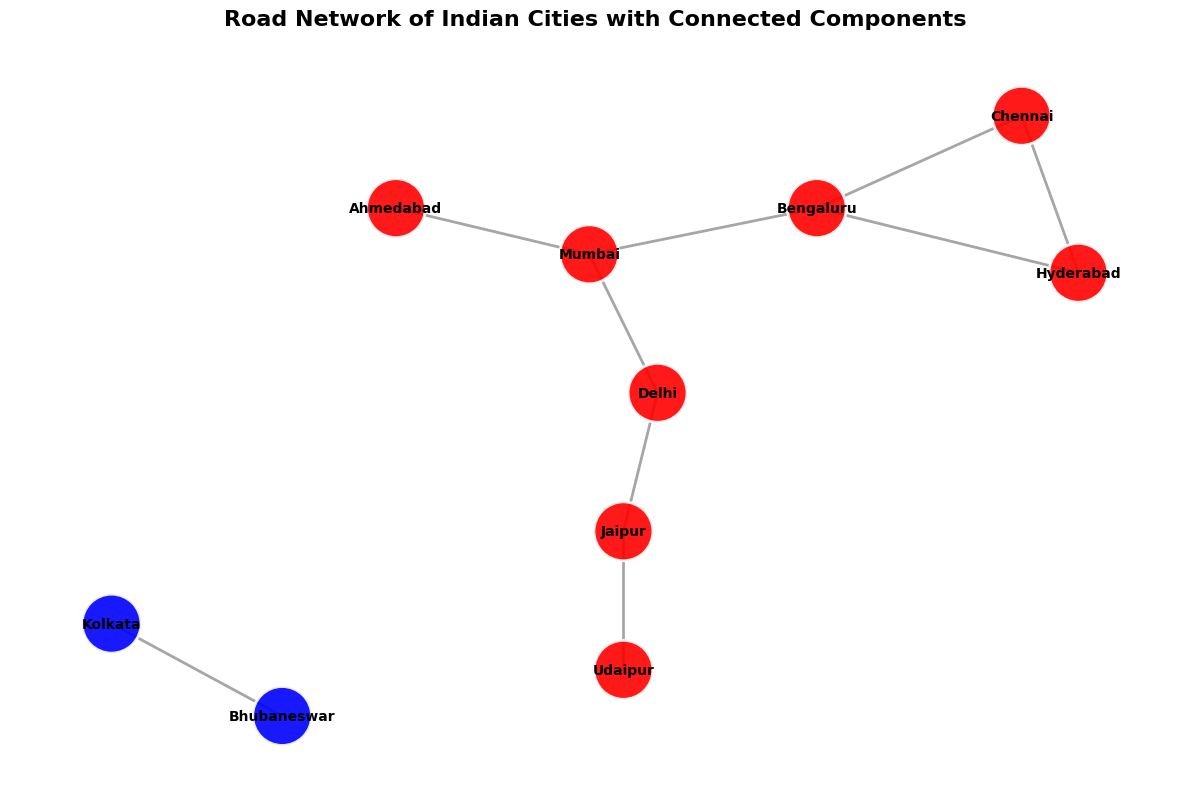

In [7]:
# Define the road network (graph) using Indian city names
# This is an undirected graph, so connections are bidirectional.
road_network = {
    'Delhi': ['Mumbai', 'Jaipur'],
    'Mumbai': ['Delhi', 'Bengaluru', 'Ahmedabad'],
    'Jaipur': ['Delhi', 'Udaipur'],
    'Bengaluru': ['Mumbai', 'Chennai', 'Hyderabad'],
    'Chennai': ['Bengaluru', 'Hyderabad'],
    'Hyderabad': ['Bengaluru', 'Chennai'],
    'Ahmedabad': ['Mumbai'],
    'Kolkata': ['Bhubaneswar'],
    'Bhubaneswar': ['Kolkata']
}

def find_connected_components(graph):
    """
    Finds all separate groups of cities that are connected to each other.
    """
    visited = set()
    components = []

    for city in graph:
        if city not in visited:
            current_component = set()
            stack = [city]
            visited.add(city)

            while stack:
                node = stack.pop()
                current_component.add(node)
                for neighbor in graph.get(node, []):
                    if neighbor not in visited:
                        visited.add(neighbor)
                        stack.append(neighbor)
            components.append(sorted(list(current_component)))
    return components

connected_groups = find_connected_components(road_network)

import networkx as nx
import matplotlib.pyplot as plt

# Create a graph object
G = nx.Graph()

# Add nodes
G.add_nodes_from(road_network.keys())

# Add edges
for city, connections in road_network.items():
    for connected_city in connections:
        # Ensure we only add edges once in an undirected graph
        if not G.has_edge(city, connected_city):
            G.add_edge(city, connected_city)

# ---------------------------------------------------------
# Colors for connected components
# ---------------------------------------------------------

colors = ['red', 'blue'] # Main component -> red, Kolkata-Bhubaneswar -> blue
node_colors = []

for node in G.nodes():
    for i, component in enumerate(connected_groups):
        if node in component:
            node_colors.append(colors[i])
            break

# ---------------------------------------------------------
# Custom positions to prevent overlap and ensure separation
# ---------------------------------------------------------

pos = {
    # Main connected component
    'Ahmedabad': (1.5, 5.5),
    'Mumbai': (3.2, 5.0),
    'Delhi': (3.8, 3.5),
    'Jaipur': (3.5, 2.0),
    'Udaipur': (3.5, 0.5),

    # Southern cities
    'Bengaluru': (5.2, 5.5),
    'Chennai': (7.0, 6.5),
    'Hyderabad': (7.5, 4.8),

    # Separate component (adjusted for better spacing)
    'Kolkata': (-1.0, 1.0),
    'Bhubaneswar': (0.5, 0.0)
}

# ---------------------------------------------------------
# Draw graph
# ---------------------------------------------------------

plt.figure(figsize=(12, 8))

# Draw edges first
nx.draw_networkx_edges(
    G,
    pos,
    width=2,
    edge_color='gray',
    alpha=0.7
)

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=1800,
    alpha=0.9,
    edgecolors='white',
    linewidths=2
)

# Draw labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight='bold',
    font_color='black'
)

# Title
plt.title(
    'Road Network of Indian Cities with Connected Components',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.axis('off')
plt.tight_layout()
plt.show()